In [326]:
import os
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from scipy.optimize import linear_sum_assignment

In [327]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "low_grade_glioma"
pseudobulk = False
ncells = "null"
rd = 1
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

In [328]:
def all_samples_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    if pseudobulk:
        fig_name = f"pseudobulk_{dataset}_{tool}_rd{rd}_ncells{ncells}_all_samples_similarity_matrix"
    else:
        fig_name = f"{dataset}_{tool}_rd{rd}_all_samples_similarity_matrix"

    # Visualize ALL samples against ALL samples
    extreme_point = max(
        abs(matrix_df.min().min()), abs(matrix_df.max().max())
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap)

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=45, ha="left", fontdict={"fontsize": 10})
    ax.set_yticklabels(matrix_df.index, fontdict={"fontsize": 10})
    ax.xaxis.set_label_position("top")
    ax.set_title(f"{tool} Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

In [329]:
def bulk_vs_singlecell_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    if pseudobulk == True:
        fig_name = f"pseudobulk_{dataset}_{tool}_rd{rd}_ncells{ncells}_bulk_vs_singlecell_similarity_matrix"
    else:
        fig_name = f"{dataset}_{tool}_rd{rd}_bulk_vs_singlecell_similarity_matrix"

    # Visualize bulk against single-cell or single-nucleus samples
    sub_matrix = matrix_df[
        [col for col in matrix_df.columns if "single-cell" in col or "single-nucleus" in col]
    ]
    sub_matrix = sub_matrix.loc[
        [idx for idx in sub_matrix.index if "bulk" in idx]
    ]

    extreme_point = max(
        abs(sub_matrix.min().min()), abs(sub_matrix.max().max())
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap)

    ax.set_xticks(np.arange(len(sub_matrix.columns)))
    ax.set_yticks(np.arange(len(sub_matrix.index)))
    ax.set_xticklabels(sub_matrix.columns, rotation=45, ha="left")
    ax.set_yticklabels(sub_matrix.index)
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Single-cell samples")
    ax.set_ylabel("Bulk samples")
    ax.set_title(f"{tool} Bulk vs Single-cell Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH, f"{fig_name}.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

# Vireo

In [330]:
if pseudobulk:
    vireo_matrix = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/similarity_matrix.csv", index_col=0)
else:
    vireo_matrix = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/real_data/ncells_{ncells}/read_depth_{rd}/similarity_matrix.csv", index_col=0)

In [331]:
vireo_matrix.columns = [re.sub(r"[a-zA-Z0-9]{32}_", "", col.replace(".bam", "").replace("ds.", "")) for col in vireo_matrix.columns]
vireo_matrix.index = pd.Index([re.sub(r"[a-zA-Z0-9]{32}_", "", idx.replace(".bam", "").replace("ds.", "")) for idx in vireo_matrix.index])

In [332]:
# Order rows and columns
ordered_columns = sorted(vireo_matrix.columns)
ordered_index = sorted(vireo_matrix.index)
vireo_matrix = vireo_matrix.loc[ordered_index, ordered_columns]

In [333]:
vireo_matrix.head()

,GSM7326880_single-cell,GSM7326881_single-cell,GSM7326884_single-cell,GSM7326886_single-cell,GSM7326891_single-cell,GSM7326900_single-cell,GSM7326901_single-cell,GSM7326903_single-cell
GSM7326906_bulk,0.010424,0.012491,0.009243,0.007796,0.012539,0.010718,0.010009,0.010561
GSM7326907_bulk,0.009864,0.011933,0.008652,0.007152,0.011968,0.010122,0.009404,0.009958
GSM7326908_bulk,0.008867,0.010940,0.007677,0.006235,0.010967,0.009242,0.008508,0.009073
GSM7326909_bulk,0.013941,0.016014,0.012752,0.011306,0.016041,0.014147,0.013416,0.013973
GSM7326910_bulk,0.012314,0.014383,0.011113,0.009662,0.014407,0.012537,0.011787,0.012340


In [334]:
vireo_matrix.shape

(8, 8)

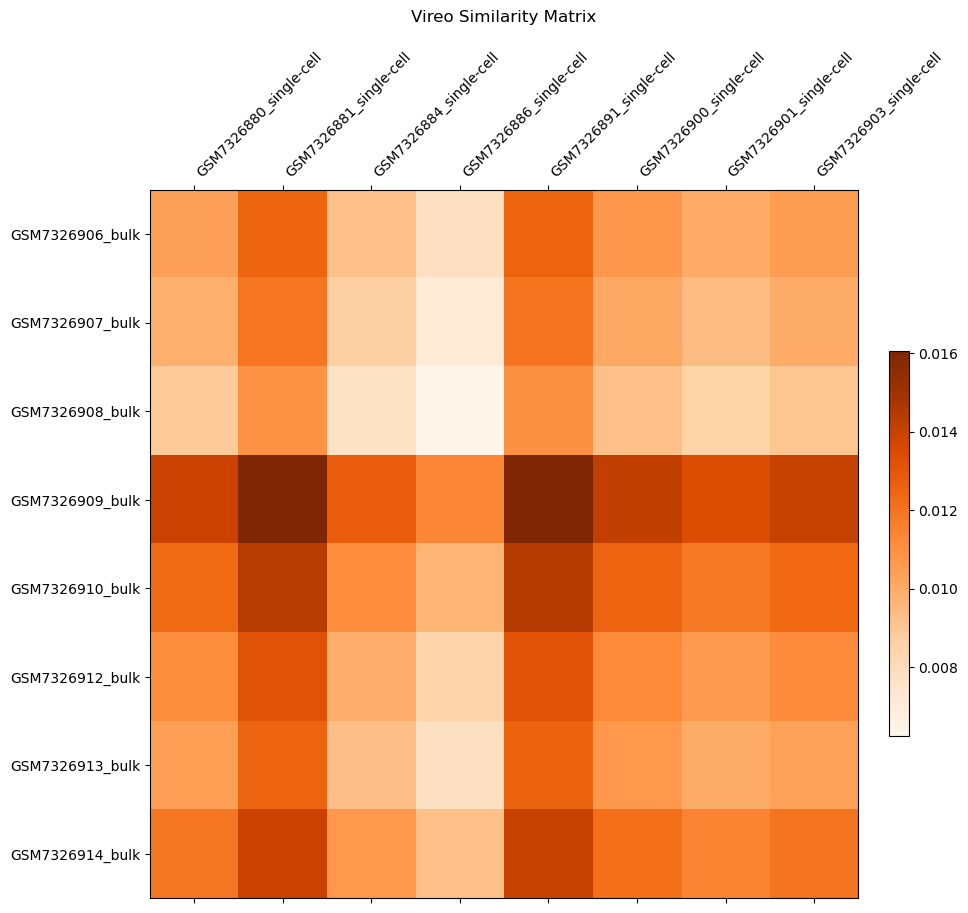

In [335]:
all_samples_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=True)

## Pseudobulk accuracy

In [336]:
if pseudobulk:
    vireo_matches = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/matched_samples.csv", index_col=0).reset_index()
else:
    vireo_matches = pd.read_csv(DATA_PATH + f"2a_vireo/{dataset}/real_data/ncells_{ncells}/read_depth_{rd}/matched_samples.csv", index_col=0).reset_index()

In [337]:
for col in vireo_matches.columns:
    vireo_matches[col] = [re.sub(r"[a-zA-Z0-9]{32}_", "", sample.replace(".bam", "").replace("ds.", "")) for sample in vireo_matches[col]]

vireo_matches = vireo_matches.sort_values(by=["sample_id_0"]).reset_index(drop=True)

In [338]:
vireo_matches

,sample_id_0,sample_id_1
0,GSM7326880_single-cell,GSM7326906_bulk
1,GSM7326881_single-cell,GSM7326914_bulk
2,GSM7326884_single-cell,GSM7326910_bulk
3,GSM7326886_single-cell,GSM7326907_bulk
4,GSM7326891_single-cell,GSM7326908_bulk
5,GSM7326900_single-cell,GSM7326912_bulk
6,GSM7326901_single-cell,GSM7326909_bulk
7,GSM7326903_single-cell,GSM7326913_bulk


In [324]:
# How many correct matches?
correct_matches = vireo_matches[vireo_matches["sample_id_0"] == vireo_matches["sample_id_1"]]
print(f"Number of correct matches: {correct_matches.shape[0]} out of {vireo_matches.shape[0]}")

Number of correct matches: 0 out of 30


In [86]:
# Filter Vireo matrix to only samples ending in _1 in rows and samples ending in _2 in columns
vireo_matrix_filtered = vireo_matrix.loc[
    [idx for idx in vireo_matrix.index if idx.endswith("_2")],
    [col for col in vireo_matrix.columns if col.endswith("_3")]
]
# Remove sample with sample_id GSM6467408 in the name
# vireo_matrix_filtered = vireo_matrix_filtered.drop(
#     [idx for idx in vireo_matrix_filtered.index if "GSM6467408" in idx],
#     axis=0
# )
# vireo_matrix_filtered = vireo_matrix_filtered.drop(
#     [col for col in vireo_matrix_filtered.columns if "GSM6467408" in col],
#     axis=1
# )

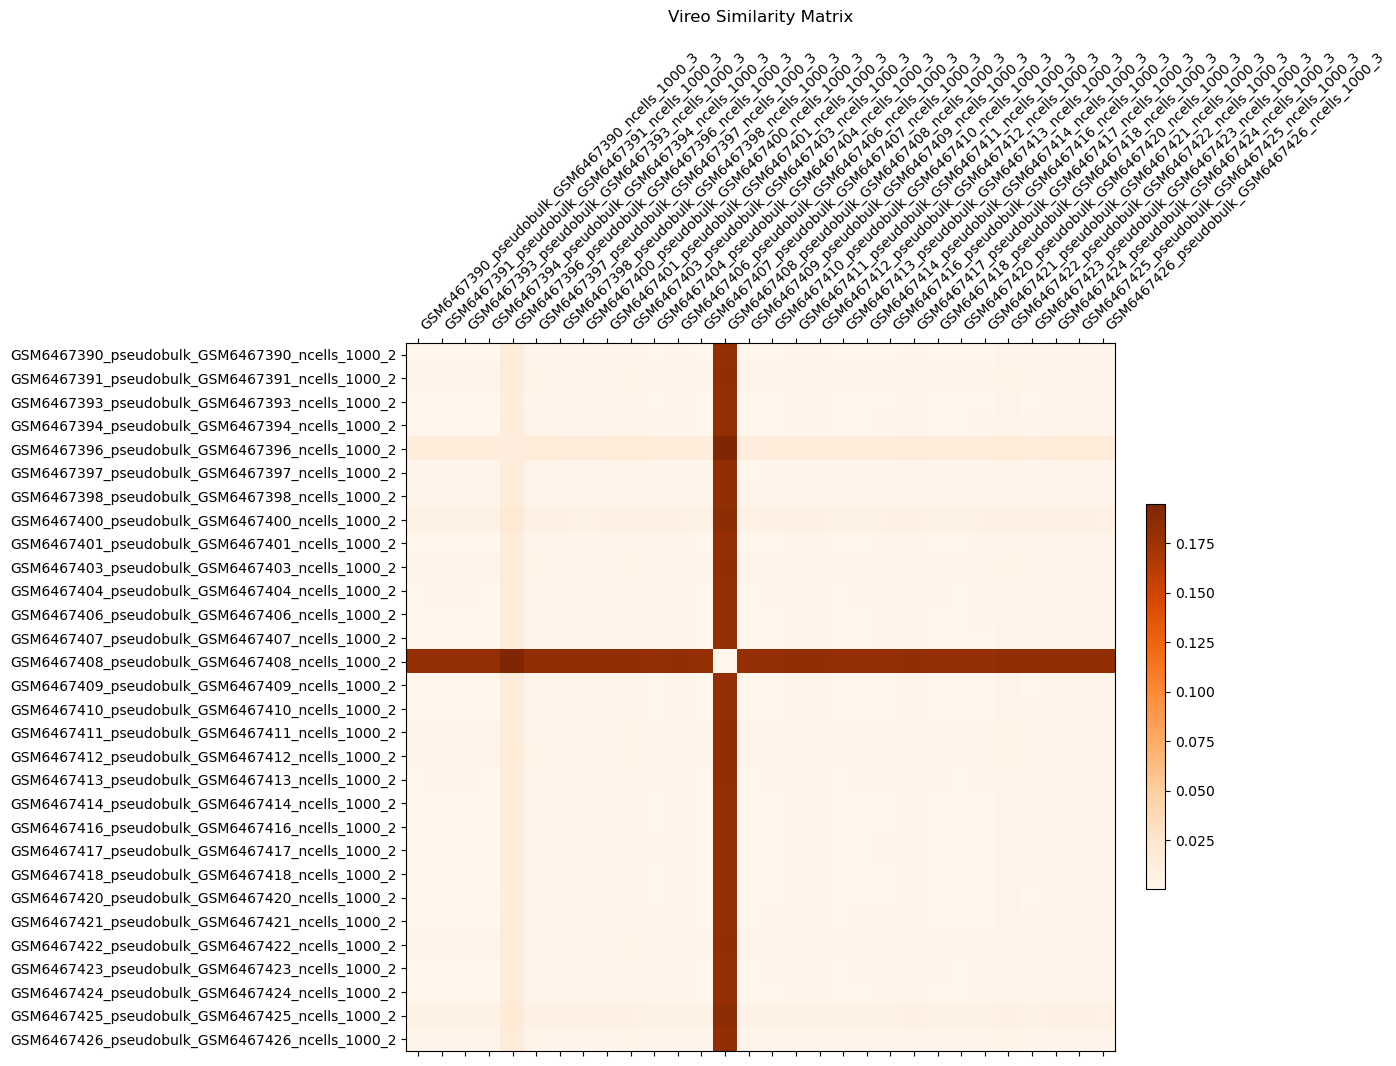

In [87]:
all_samples_matrix_viz(vireo_matrix_filtered, tool="Vireo", dataset=dataset, save_fig=True)

In [88]:
# Minimize diagonal of vireo_matrix_filtered by moving rows and columns around
idx0, idx1 = linear_sum_assignment(vireo_matrix_filtered.values)
vireo_matrix_reordered = pd.DataFrame(vireo_matrix_filtered.iloc[idx0, idx1], index=vireo_matrix_filtered.index[idx0], columns=vireo_matrix_filtered.columns[idx1])

In [89]:
# Check if the rows and columns have the same samples in the same order
vireo_matrix_reordered.index = [re.sub(r"_2$", "", idx) for idx in vireo_matrix_reordered.index]
vireo_matrix_reordered.columns = [re.sub(r"_3$", "", col) for col in vireo_matrix_reordered.columns]

In [ ]:
vireo_matches_reordered = pd.DataFrame({
    "sample_id_0": vireo_matrix_reordered.index,
    "sample_id_1": vireo_matrix_reordered.columns
})
# How many correct matches?
correct_matches = vireo_matches_reordered[vireo_matches_reordered["sample_id_0"] == vireo_matches_reordered["sample_id_1"]]
print(f"Number of correct matches: {correct_matches.shape[0]} out of {vireo_matches_reordered.shape[0]}")

In [ ]:
incorrect_matches = vireo_matches_reordered[vireo_matches_reordered["sample_id_0"] != vireo_matches_reordered["sample_id_1"]]
incorrect_matches

In [ ]:
vireo_matrix_reordered.head()

# NGSCheckmate

In [354]:
if pseudobulk:  
    ngscheckmate_df = pd.read_csv(DATA_PATH + f"2a_ngscheckmate/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/output_all.txt", sep="\t", index_col=0, header=None)
else:
    ngscheckmate_df = pd.read_csv(DATA_PATH + f"2a_ngscheckmate/{dataset}/real_data/ncells_{ncells}/read_depth_{rd}/output_all.txt", sep="\t", index_col=0, header=None)

In [355]:
ngscheckmate_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".vcf", "").replace("ds.", "").replace("_individual_variants", ""))
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [356]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
GSM7326880_single-cell,matched,GSM7326881_single-cell,0.4658,0.02
GSM7326880_single-cell,unmatched,GSM7326883_single-cell,-0.1492,0.02
GSM7326880_single-cell,unmatched,GSM7326884_single-cell,-0.4448,0.02
GSM7326880_single-cell,unmatched,GSM7326885_single-cell,-0.1644,0.02
GSM7326880_single-cell,unmatched,GSM7326886_single-cell,-0.3254,0.02


In [365]:
ngscheckmate_df.index

Index(['GSM7326880_single-cell', 'GSM7326880_single-cell',
       'GSM7326880_single-cell', 'GSM7326880_single-cell',
       'GSM7326880_single-cell', 'GSM7326880_single-cell',
       'GSM7326880_single-cell', 'GSM7326880_single-cell',
       'GSM7326880_single-cell', 'GSM7326880_single-cell',
       ...
       'GSM7326909_bulk', 'GSM7326909_bulk', 'GSM7326909_bulk',
       'GSM7326909_bulk', 'GSM7326910_bulk', 'GSM7326910_bulk',
       'GSM7326910_bulk', 'GSM7326912_bulk', 'GSM7326912_bulk',
       'GSM7326913_bulk'],
      dtype='object', name=0, length=435)

In [370]:
def long_df_to_matrix_ngscheckmate(df):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index=0,
        columns='Sample',
        values='Correlation',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Convert correlation values to percentage (divide by 100)
    matrix = matrix / 100
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [371]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [372]:
ngscheckmate_matrix.head()

,GSM7326906_bulk,GSM7326907_bulk,GSM7326908_bulk,GSM7326909_bulk,GSM7326910_bulk,GSM7326912_bulk,GSM7326913_bulk,GSM7326914_bulk,GSM7326880_single-cell,GSM7326881_single-cell,...,GSM7326894_single-cell,GSM7326895_single-cell,GSM7326896_single-cell,GSM7326898_single-cell,GSM7326899_single-cell,GSM7326900_single-cell,GSM7326901_single-cell,GSM7326902_single-cell,GSM7326903_single-cell,GSM7326905_single-cell
0,,,,,,,,,,,,,,,,,,,,,
GSM7326906_bulk,NaN,0.0029,0.0017,0.0029,0.0029,0.0029,0.0029,0.0029,0.0002,0.0004,...,0.0028,0.0025,0.0029,0.0029,0.0006,0.0007,0.0006,0.0008,0.0009,0.0003
GSM7326907_bulk,0.0029,NaN,0.0017,0.0064,0.0064,0.0064,0.0064,0.0036,0.0002,0.0004,...,0.0028,0.0025,0.0038,0.0045,0.0006,0.0007,0.0006,0.0008,0.0009,0.0003
GSM7326908_bulk,0.0017,0.0017,NaN,0.0017,0.0017,0.0017,0.0017,0.0017,0.0002,0.0004,...,0.0017,0.0017,0.0017,0.0017,0.0006,0.0007,0.0006,0.0008,0.0009,0.0003
GSM7326909_bulk,0.0029,0.0064,0.0017,NaN,0.0074,0.0074,0.0076,0.0036,0.0002,0.0004,...,0.0028,0.0025,0.0038,0.0045,0.0006,0.0007,0.0006,0.0008,0.0009,0.0003
GSM7326910_bulk,0.0029,0.0064,0.0017,0.0074,NaN,0.0074,0.0074,0.0036,0.0002,0.0004,...,0.0028,0.0025,0.0038,0.0045,0.0006,0.0007,0.0006,0.0008,0.0009,0.0003


In [ ]:
# all_samples_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

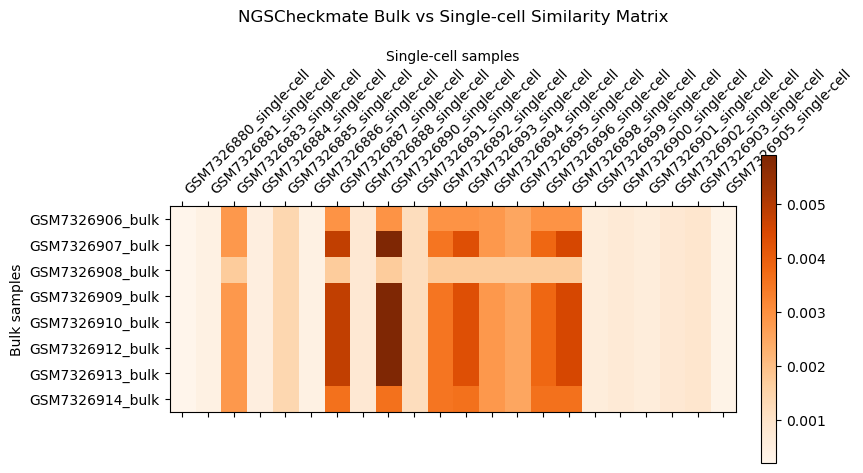

In [373]:
bulk_vs_singlecell_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

## Real data accuracy

In [425]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
GSM7326880_single-cell,matched,GSM7326881_single-cell,0.4658,0.02
GSM7326880_single-cell,unmatched,GSM7326883_single-cell,-0.1492,0.02
GSM7326880_single-cell,unmatched,GSM7326884_single-cell,-0.4448,0.02
GSM7326880_single-cell,unmatched,GSM7326885_single-cell,-0.1644,0.02
GSM7326880_single-cell,unmatched,GSM7326886_single-cell,-0.3254,0.02


In [435]:
ngscheckmate_sub_df = ngscheckmate_df[ngscheckmate_df['Sample'].str.contains("bulk") & ngscheckmate_df.index.str.contains('single-cell')]

In [454]:
ngscheckmate_sub_df[
    (ngscheckmate_sub_df["Sample"]=="GSM7326914_bulk") & 
    (ngscheckmate_sub_df.index=="GSM7326905_single-cell")
    ]

,Matched,Sample,Binary,Correlation
0,,,,
GSM7326905_single-cell,unmatched,GSM7326914_bulk,0.0217,0.03


In [456]:
ngscheckmate_sub_df["Matched"].value_counts()


Matched
unmatched    137
matched       39
Name: count, dtype: int64

# HYSYS

In [383]:
if pseudobulk:
    hysys_df = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/concordance_output.txt", sep="\t", index_col=0, header=None)
else:
    hysys_df = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/real_data/ncells_null/read_depth_{rd}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [384]:
hysys_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace(f"{dataset}/", "").replace("_individual_variants.snps", "").replace("pseudobulk/", "").replace("real_data/", "").replace(f"ncells_{ncells}/", "").replace(f"read_depth_{rd}/", ""))
    # x.replace("_filtered_variants.snps", "").replace(f"{dataset}/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [385]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
GSM7326906_bulk,GSM7326880_single-cell,0.001,26729
GSM7326906_bulk,GSM7326881_single-cell,0.001,32328
GSM7326906_bulk,GSM7326883_single-cell,0.005,106777
GSM7326906_bulk,GSM7326884_single-cell,0.001,23459
GSM7326906_bulk,GSM7326885_single-cell,0.010,40232


In [394]:
def long_df_to_matrix_hysys(df):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index=0,
        columns='Sample',
        values='Concordance',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [395]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [396]:
hysys_matrix.head()

,GSM7326906_bulk,GSM7326907_bulk,GSM7326908_bulk,GSM7326909_bulk,GSM7326910_bulk,GSM7326912_bulk,GSM7326913_bulk,GSM7326914_bulk,GSM7326880_single-cell,GSM7326881_single-cell,...,GSM7326894_single-cell,GSM7326895_single-cell,GSM7326896_single-cell,GSM7326898_single-cell,GSM7326899_single-cell,GSM7326900_single-cell,GSM7326901_single-cell,GSM7326902_single-cell,GSM7326903_single-cell,GSM7326905_single-cell
0,,,,,,,,,,,,,,,,,,,,,
GSM7326906_bulk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,0.001,...,0.009,0.004,0.007,0.005,0.009,0.010,0.011,0.010,0.011,0.005
GSM7326907_bulk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,0.001,...,0.013,0.005,0.008,0.007,0.012,0.013,0.015,0.012,0.014,0.006
GSM7326908_bulk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,0.001,...,0.007,0.003,0.005,0.004,0.009,0.008,0.010,0.008,0.010,0.005
GSM7326909_bulk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001,0.001,...,0.011,0.004,0.012,0.007,0.010,0.010,0.012,0.011,0.011,0.006
GSM7326910_bulk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002,0.001,...,0.013,0.005,0.009,0.010,0.012,0.012,0.014,0.013,0.013,0.006


In [398]:
# all_samples_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

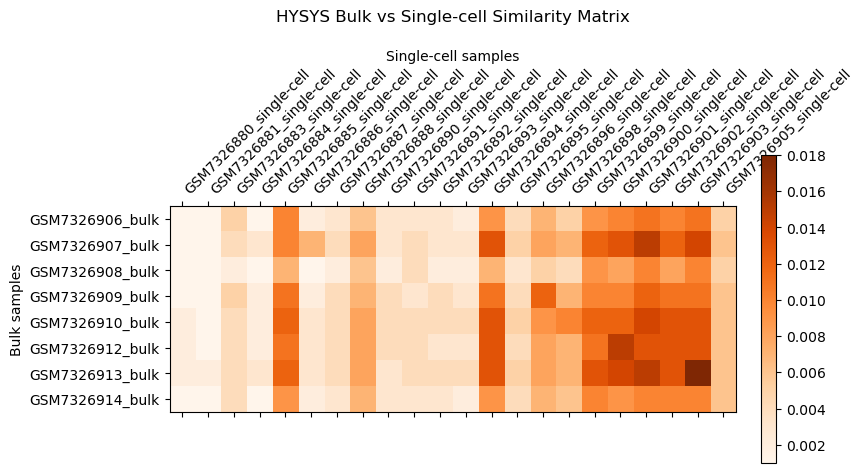

In [ ]:
bulk_vs_singlecell_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

## Pseudobulk accuracy

In [418]:
if pseudobulk:
    hysys_matches = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/model_results.txt", sep=",", skiprows=9, header=None)
else:
    hysys_matches = pd.read_csv(DATA_PATH + f"2a_hysys/{dataset}/real_data/ncells_null/read_depth_{rd}/model_results.txt", sep=",", skiprows=9, header=None)

In [422]:
hysys_matches

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,sample low_grade_glioma/real_data/ncells_null/...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...
1,sample low_grade_glioma/real_data/ncells_null/...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...
2,sample low_grade_glioma/real_data/ncells_null/...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...
3,sample low_grade_glioma/real_data/ncells_null/...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_...,'low_grade_glioma/real_data/ncells_null/read_.

In [419]:
# Clean up hysys_matches to extract sample IDs from filepaths
hysys_matches.columns = ["Sample_1", "Sample_2", "Status"]
hysys_matches["Sample_1"] = hysys_matches["Sample_1"].str.replace(r".*/(.*?)\.snps", r"\1", regex=True)
hysys_matches["Sample_2"] = hysys_matches["Sample_2"].str.replace(r".*/(.*?)\.snps", r"\1", regex=True)

# Apply the same regex cleanup as other tools
for col in ["Sample_1", "Sample_2"]:
    hysys_matches[col] = [re.sub(r"[a-zA-Z0-9]{32}_", "", sample.replace("_individual_variants", "").replace("ds.", "")) for sample in hysys_matches[col]]

hysys_matches.head()

ValueError: Length mismatch: Expected axis has 22 elements, new values have 3 elements

In [ ]:
# Filter HYSYS matrix to only samples ending in _1 in rows and samples ending in _2 in columns
hysys_matrix_filtered = hysys_matrix.loc[
    [idx for idx in hysys_matrix.index if idx.endswith("_2")],
    [col for col in hysys_matrix.columns if col.endswith("_3")]
]

In [ ]:
all_samples_matrix_viz(hysys_matrix_filtered, tool="HYSYS", dataset=dataset, save_fig=True)

# CrossCheckFingerprints

In [ ]:
if pseudobulk:
    fingerprints_df = pd.read_csv(DATA_PATH + f"2a_fingerprints/{dataset}/pseudobulk/ncells_{ncells}/read_depth_{rd}/crosscheck_metrics.txt", sep="\t", skiprows=6, header=0)
else:
    fingerprints_df = pd.read_csv(DATA_PATH + f"2a_fingerprints/{dataset}/real_data/ncells_null/read_depth_{rd}/crosscheck_metrics.txt", sep="\t", skiprows=6, header=0)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [ ]:
fingerprints_dict = {
    x: 
    # x.replace(".bam", "")
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace("ds.", ""))
    
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [ ]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7326884_single-cell,GSM7326884_single-cell,3.255386,EXPECTED_MATCH
1,GSM7326884_single-cell,GSM7326913_bulk,-0.507481,EXPECTED_MISMATCH
2,GSM7326884_single-cell,GSM7326893_single-cell,0.688052,UNEXPECTED_MATCH
3,GSM7326884_single-cell,GSM7326885_single-cell,0.427261,UNEXPECTED_MATCH
4,GSM7326884_single-cell,GSM7326883_single-cell,-0.381197,EXPECTED_MISMATCH


In [ ]:
def long_df_to_matrix_fingerprints(df):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index='LEFT_SAMPLE',
        columns='RIGHT_SAMPLE', 
        values='LOD_SCORE',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df['LEFT_SAMPLE']) | set(df['RIGHT_SAMPLE']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [ ]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [ ]:
fingerprints_matrix.head()

,GSM7326906_bulk,GSM7326907_bulk,GSM7326908_bulk,GSM7326909_bulk,GSM7326910_bulk,GSM7326912_bulk,GSM7326913_bulk,GSM7326914_bulk,GSM7326880_single-cell,GSM7326881_single-cell,...,GSM7326894_single-cell,GSM7326895_single-cell,GSM7326896_single-cell,GSM7326898_single-cell,GSM7326899_single-cell,GSM7326900_single-cell,GSM7326901_single-cell,GSM7326902_single-cell,GSM7326903_single-cell,GSM7326905_single-cell
LEFT_SAMPLE,,,,,,,,,,,,,,,,,,,,,
GSM7326906_bulk,22.032301,5.344183,-5.747204,-3.395043,1.295250,-1.001775,1.239508,2.299853,0.000000,0.000000,...,0.598772,0.988451,-0.329292,-0.886813,1.494955,1.018979,-1.135701,2.074723,0.268461,-0.012391
GSM7326907_bulk,5.344183,29.649940,-10.057516,1.511550,-9.676060,-0.530626,8.004422,4.430138,-2.330802,0.245428,...,-0.483960,0.013125,-1.980318,-0.428383,3.351797,1.002628,0.079742,-0.219845,0.736982,1.522613
GSM7326908_bulk,-5.747204,-10.057516,18.233964,-1.764659,-8.325847,-12.406236,-11.292253,-6.937425,0.000000,0.000000,...,-3.291369,-2.099077,-1.945722,0.088702,-1.712906,-1.963543,-0.900559,-2.247349,-1.945722,-3.558700
GSM7326909_bulk,-3.395043,1.511550,-1.764659,38.432606,-5.454045,-3.988264,-7.594643,1.134026,0.329098,0.254490,...,0.139716,2.657232,5.506243,4.179543,2.499354,-1.732030,2.911506,-0.007966,-1.577501,3.121588
GSM7326910_bulk,1.295250,-9.676060,-8.325847,-5.454045,35.230022,-6.580327,-9.606244,1.354508,0.329098,0.000000,...,1.975658,3.269702,2.401440,5.027975,1.423352,-0.371948,1.889600,1.225300,-1.302649,2.943891


In [406]:
fingerprints_matrix.shape

(30, 30)

In [ ]:
# all_samples_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

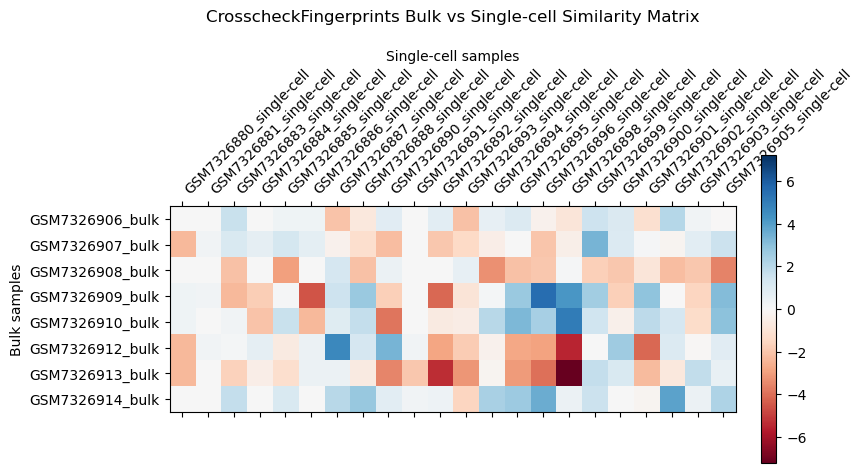

In [ ]:
bulk_vs_singlecell_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

In [457]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7326884_single-cell,GSM7326884_single-cell,3.255386,EXPECTED_MATCH
1,GSM7326884_single-cell,GSM7326913_bulk,-0.507481,EXPECTED_MISMATCH
2,GSM7326884_single-cell,GSM7326893_single-cell,0.688052,UNEXPECTED_MATCH
3,GSM7326884_single-cell,GSM7326885_single-cell,0.427261,UNEXPECTED_MATCH
4,GSM7326884_single-cell,GSM7326883_single-cell,-0.381197,EXPECTED_MISMATCH


In [458]:
fingerprints_df["RESULT"].value_counts()

RESULT
UNEXPECTED_MATCH     486
EXPECTED_MISMATCH    326
INCONCLUSIVE          58
EXPECTED_MATCH        30
Name: count, dtype: int64

In [459]:
# Confirmed that the expected matches are simply the samples matching themselves
fingerprint_exp_matches = fingerprints_df[fingerprints_df["RESULT"]=="EXPECTED_MATCH"]
fingerprint_exp_matches[fingerprint_exp_matches["LEFT_SAMPLE"] != fingerprint_exp_matches["RIGHT_SAMPLE"]]

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT


In [460]:
fingerprints_matches = fingerprints_df[fingerprints_df["RESULT"]=="UNEXPECTED_MATCH"]

In [494]:
presumed_matches_df = pd.read_csv(
    DATA_PATH + f"../metadata/sample_matches/sample_matches_{dataset}.csv"
    ).dropna(how="all", axis=1).dropna(how="any")

In [501]:
presumed_matches_df["bulk"] = presumed_matches_df["bulk"] + "_bulk"
presumed_matches_df["single-cell"] = presumed_matches_df["single-cell"] + "_single-cell"

In [502]:
presumed_matches_df

,bulk,single-cell
2,GSM7326906_bulk,GSM7326883_single-cell
5,GSM7326907_bulk,GSM7326886_single-cell
9,GSM7326908_bulk,GSM7326891_single-cell
14,GSM7326909_bulk,GSM7326896_single-cell
15,GSM7326910_bulk,GSM7326898_single-cell
17,GSM7326912_bulk,GSM7326900_single-cell
20,GSM7326913_bulk,GSM7326903_single-cell
21,GSM7326914_bulk,GSM7326905_single-cell


In [507]:
# Find all lines in fingerprints_df that have the bulk and single-cell pairs from presumed_matches_df
# Check both directions since pairs could be in either LEFT_SAMPLE/RIGHT_SAMPLE order

# Create sets for faster lookup
bulk_samples = set(presumed_matches_df["bulk"])
sc_samples = set(presumed_matches_df["single-cell"])

# Find matches in both directions
bulk_left_sc_right = fingerprints_df[
    fingerprints_df["LEFT_SAMPLE"].isin(bulk_samples) & 
    fingerprints_df["RIGHT_SAMPLE"].isin(sc_samples)
]

# Combine both directions and remove duplicates
all_presumed_matches = bulk_left_sc_right.drop_duplicates()

# Now filter to only the actual expected pairs
expected_pairs = []
for _, row in presumed_matches_df.iterrows():
    bulk_sample = row["bulk"]
    sc_sample = row["single-cell"]
    
    # Check both directions
    pair_matches = all_presumed_matches[
        ((all_presumed_matches["LEFT_SAMPLE"] == bulk_sample) & 
         (all_presumed_matches["RIGHT_SAMPLE"] == sc_sample)) |
        ((all_presumed_matches["LEFT_SAMPLE"] == sc_sample) & 
         (all_presumed_matches["RIGHT_SAMPLE"] == bulk_sample))
    ]
    expected_pairs.append(pair_matches)

presumed_pairs_results = pd.concat(expected_pairs) if expected_pairs else pd.DataFrame()

print(f"Found {len(all_presumed_matches)} total bulk-single-cell comparisons")
print(f"Found {len(presumed_pairs_results)} comparisons for the expected pairs")
print("\nExpected pairs results:")
presumed_pairs_results

Found 64 total bulk-single-cell comparisons
Found 8 comparisons for the expected pairs

Expected pairs results:


,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
394,GSM7326906_bulk,GSM7326883_single-cell,1.599053,UNEXPECTED_MATCH
878,GSM7326907_bulk,GSM7326886_single-cell,0.705372,UNEXPECTED_MATCH
307,GSM7326908_bulk,GSM7326891_single-cell,0.000000,INCONCLUSIVE
704,GSM7326909_bulk,GSM7326896_single-cell,5.506243,UNEXPECTED_MATCH
655,GSM7326910_bulk,GSM7326898_single-cell,5.027975,UNEXPECTED_MATCH
528,GSM7326912_bulk,GSM7326900_single-cell,2.545403,UNEXPECTED_MATCH
45,GSM7326913_bulk,GSM7326903_single-cell,1.787434,UNEXPECTED_MATCH
624,GSM7326914_bulk,GSM7326905_single-cell,2.216564,UNEXPECTED_MATCH


In [513]:
bulk_left_sc_right = fingerprints_df[
    fingerprints_df["LEFT_SAMPLE"].str.contains("bulk") & 
    fingerprints_df["RIGHT_SAMPLE"].str.contains("single-cell")
]

In [516]:
bulk_left_sc_right["RESULT"].value_counts()

RESULT
UNEXPECTED_MATCH     85
EXPECTED_MISMATCH    72
INCONCLUSIVE         19
Name: count, dtype: int64

In [476]:
# HGSOC
# Out of 80 unexpected matches
# There should be really only 40 pairs since it's symmetric
#
# 5/40 are polyA vs polyA (and they all involve sample 2507)
# 0 are ribo vs ribo
# 35/40 are polyA vs ribo

# CNST
# Out of 938 unexpected matches
# 
# 317/469 are bulk vs bulk
# 10/469 are sn vs sn
fingerprints_matches[
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("bulk") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("bulk")) &
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("cell") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("cell"))
].sort_values(
    by=["LEFT_SAMPLE", "RIGHT_SAMPLE"]
).drop_duplicates(
    "LOD_SCORE"
).reset_index(
    drop=True
)

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7326880_single-cell,GSM7326909_bulk,0.329098,UNEXPECTED_MATCH
1,GSM7326881_single-cell,GSM7326907_bulk,0.245428,UNEXPECTED_MATCH
2,GSM7326881_single-cell,GSM7326909_bulk,0.254490,UNEXPECTED_MATCH
3,GSM7326881_single-cell,GSM7326912_bulk,0.250071,UNEXPECTED_MATCH
4,GSM7326883_single-cell,GSM7326906_bulk,1.599053,UNEXPECTED_MATCH
...,...,...,...,...
78,GSM7326905_single-cell,GSM7326909_bulk,3.121588,UNEXPECTED_MATCH
79,GSM7326905_single-cell,GSM7326910_bulk,2.943891,UNEXPECTED_MATCH
80,GSM7326905_single-cell,GSM7326912_bulk,0.827976,UNEXPECTED_MATCH
81,GSM7326905_single-cell,GSM7326913_bulk,0.563219,UNEXPECTED_MATCH


# BAMixChecker

In [411]:
if pseudobulk:
    bamixchecker_df = pd.read_csv(DATA_PATH + f"2b_bamixchecker/{dataset}/pseudobulk/ncells_{ncells}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
else:
    bamixchecker_df = pd.read_csv(DATA_PATH + f"2b_bamixchecker/{dataset}/real_data/ncells_null/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [412]:
bamixchecker_dict = {
    x: 
    # x.replace("_filtered_rg.bam", "") 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace("_filtered_rg.bam", "").replace(f"{dataset}/", "").replace("_filtered_variants.snps", "").replace("ds.", ""))
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [413]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
GSM7326880_single-cell,GSM7326891_single-cell,0.0,Unmatched
GSM7326880_single-cell,GSM7326884_single-cell,0.0,Unmatched
GSM7326880_single-cell,GSM7326905_single-cell,0.0,Unmatched
GSM7326880_single-cell,GSM7326899_single-cell,0.0,Unmatched
GSM7326880_single-cell,GSM7326903_single-cell,0.0,Unmatched


In [414]:
def long_df_to_matrix_bamixchecker(df):
    # Use pivot_table for much faster matrix creation
    matrix = df.pivot_table(
        index=0,
        columns='Sample',
        values='Concordance Rate',
        aggfunc='first'  # Use first value if duplicates exist
    )
    
    # Get all unique samples to create a square matrix
    all_samples = sorted(set(df.index) | set(df['Sample']))
    matrix = matrix.reindex(index=all_samples, columns=all_samples)
    
    # Make matrix symmetric by filling NaN values
    matrix = matrix.combine_first(matrix.T)
    
    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [415]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [416]:
bamixchecker_matrix.head()

,GSM7326880_single-cell,GSM7326881_single-cell,GSM7326883_single-cell,GSM7326884_single-cell,GSM7326885_single-cell,GSM7326886_single-cell,GSM7326887_single-cell,GSM7326888_single-cell,GSM7326890_single-cell,GSM7326891_single-cell,...,GSM7326903_single-cell,GSM7326905_single-cell,GSM7326906_bulk,GSM7326907_bulk,GSM7326908_bulk,GSM7326909_bulk,GSM7326910_bulk,GSM7326912_bulk,GSM7326913_bulk,GSM7326914_bulk
0,,,,,,,,,,,,,,,,,,,,,
GSM7326880_single-cell,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7326881_single-cell,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7326883_single-cell,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7326884_single-cell,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7326885_single-cell,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# all_samples_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

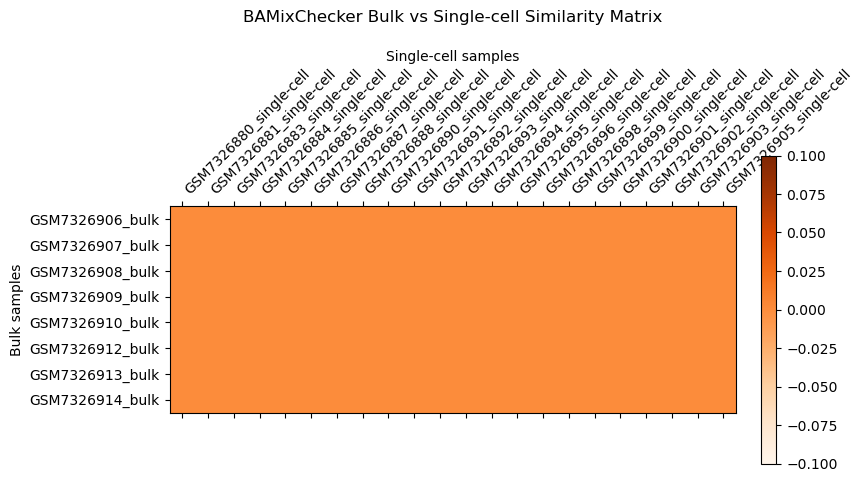

In [417]:
bulk_vs_singlecell_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

# Tool comparison

In [ ]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.png", bbox_inches="tight", dpi=300)
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.pdf", bbox_inches="tight", dpi=300